数据概览
         X1        X2        X3        X4        X5         y
0  0.413815 -0.297707  0.740306  0.116108  0.465817 -0.123018
1  1.467012 -0.294091 -0.043195  1.172921  2.516136  3.453471
2  1.653942  0.767959 -0.609331  2.421901  4.352018  4.426880
3  0.603597 -0.458720 -0.409433  0.144877  2.294446  0.151493
4  0.239872 -1.958287 -1.789982 -1.718415  2.476444 -1.439393

数据形状: (100, 6)

矩阵 X 的秩: 4 (有效特征数)
特征总数: 5
冗余维度: 1 (零空间维度)

四大子空间的维度
列空间 C(X):  维度 = 4
行空间 C(X^T): 维度 = 4
零空间 N(X):   维度 = 1
左零空间 N(X^T): 维度 = 96

零空间 N(X) 的基（维度 1）:
  组合 1: [ 0.577  0.577  0.    -0.577  0.   ]
    → 意味着: 0.58*X1 + 0.58*X2 + 0.00*X3 + -0.58*X4 + 0.00*X5 ≈ 0

零空间对回归系数的影响
最小二乘系数: [ 1.086  0.25  -1.07   1.336 -0.2  ]
截距: -0.019

加上零空间向量后: [ 6.86   6.024 -1.07  -4.437 -0.2  ]
预测差异: 0.000000 (应该接近0)

结论：零空间中的任何向量都不会改变预测值。
这就是为什么在回归中，冗余特征会导致系数不唯一。


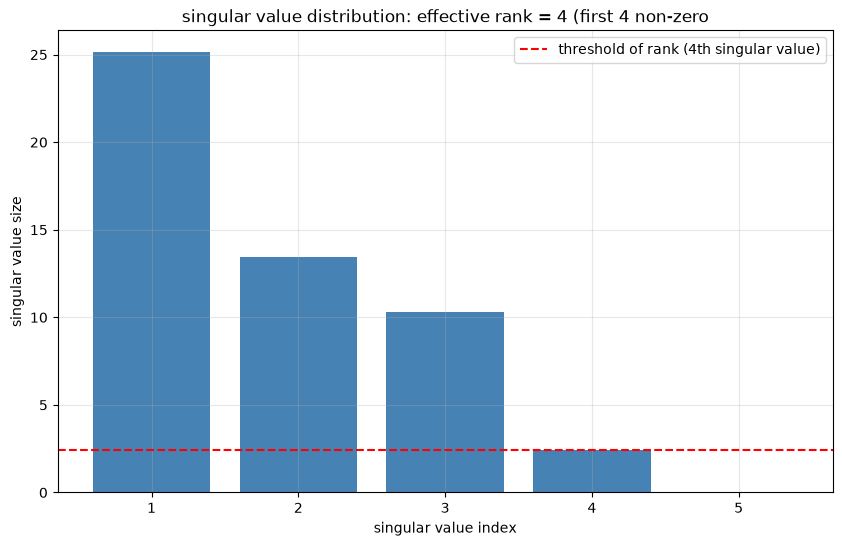

In [2]:
import numpy as np
import pandas as pd
from scipy.linalg import null_space, svd
import matplotlib.pyplot as plt

# ---- 模拟一个真实的数据矩阵 ----
np.random.seed(42)
n_samples = 100
n_features = 5

# 真实的有效特征只有3个（秩为3）
# 生成 3 个独立的潜在因子
latent = np.random.randn(n_samples, 3)

# 用线性组合生成 5 个特征（其中2个是冗余的）
# 特征1-3：直接从潜在因子生成
X_raw = np.zeros((n_samples, n_features))
X_raw[:, 0] = latent[:, 0] + 0.1 * np.random.randn(n_samples)
X_raw[:, 1] = latent[:, 1] + 0.1 * np.random.randn(n_samples)
X_raw[:, 2] = latent[:, 2] + 0.1 * np.random.randn(n_samples)
# 特征4 = 特征1 + 特征2（完全冗余）
X_raw[:, 3] = X_raw[:, 0] + X_raw[:, 1]
# 特征5 = 2*特征1 - 特征3 + 噪声（接近冗余）
X_raw[:, 4] = 2 * X_raw[:, 0] - X_raw[:, 2] + 0.5 * np.random.randn(n_samples)

# 真实的目标 y（只依赖于真正的3个特征）
y = 2 * latent[:, 0] + 1.5 * latent[:, 1] - 1.0 * latent[:, 2] + 0.5 * np.random.randn(n_samples)

# ---- 创建 DataFrame 便于查看 ----
df = pd.DataFrame(X_raw, columns=[f'X{i+1}' for i in range(n_features)])
df['y'] = y
print("=" * 60)
print("数据概览")
print("=" * 60)
print(df.head())
print(f"\n数据形状: {df.shape}")

# ---- 分析矩阵 X ----
X = X_raw
m, n = X.shape
rank = np.linalg.matrix_rank(X)
print(f"\n矩阵 X 的秩: {rank} (有效特征数)")
print(f"特征总数: {n}")
print(f"冗余维度: {n - rank} (零空间维度)")

# ---- 四大子空间的维度 ----
print("\n" + "=" * 60)
print("四大子空间的维度")
print("=" * 60)
print(f"列空间 C(X):  维度 = {rank}")
print(f"行空间 C(X^T): 维度 = {rank}")
print(f"零空间 N(X):   维度 = {n - rank}")
print(f"左零空间 N(X^T): 维度 = {m - rank}")

# ---- 找出零空间的基（冗余组合） ----
ns = null_space(X)
print(f"\n零空间 N(X) 的基（维度 {n - rank}）:")
if ns.size > 0:
    for i in range(ns.shape[1]):
        print(f"  组合 {i+1}: {ns[:, i].round(3)}")
        # 解读：这些是列之间的线性关系
        print(f"    → 意味着: {ns[0,i]:.2f}*X1 + {ns[1,i]:.2f}*X2 + {ns[2,i]:.2f}*X3 + {ns[3,i]:.2f}*X4 + {ns[4,i]:.2f}*X5 ≈ 0")

# ---- 用零空间解释系数的不稳定性 ----
print("\n" + "=" * 60)
print("零空间对回归系数的影响")
print("=" * 60)

# 用普通最小二乘求系数
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X, y)

coef = model.coef_
print(f"最小二乘系数: {coef.round(3)}")
print(f"截距: {model.intercept_:.3f}")

# 如果加上一个零空间向量，系数会变化但预测不变
if ns.size > 0:
    null_vec = ns[:, 0] * 10  # 放大一点，看得清楚
    coef_shifted = coef + null_vec
    print(f"\n加上零空间向量后: {coef_shifted.round(3)}")
    
    # 验证预测不变
    pred1 = X @ coef
    pred2 = X @ coef_shifted
    print(f"预测差异: {np.max(np.abs(pred1 - pred2)):.6f} (应该接近0)")

    print("\n结论：零空间中的任何向量都不会改变预测值。")
    print("这就是为什么在回归中，冗余特征会导致系数不唯一。")

# ---- 可视化：SVD 奇异值揭示有效秩 ----
U, S, Vt = svd(X, full_matrices=False)

# 使用英文
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(S)+1), S, color='steelblue')
# plt.axhline(y=S[rank-1], color='red', linestyle='--', label=f'秩阈值 (第{rank}个奇异值)')
plt.axhline(y=S[rank-1], color='red', linestyle='--', label=f'threshold of rank ({rank}th singular value)')
# plt.xlabel('奇异值序号')
plt.xlabel('singular value index')
# plt.ylabel('奇异值大小')
plt.ylabel('singular value size')
# plt.title(f'奇异值分布：有效秩 = {rank} (前 {rank} 个非零)')
plt.title(f'singular value distribution: effective rank = {rank} (first {rank} non-zero')
plt.legend()
plt.grid(alpha=0.3)
plt.show()